# TP5 - Imputation Avancée (KNN, MICE)

**Difficulté:** Intermédiaire  
**Dataset:** housing_missing.csv  
**Description:** Techniques d'imputation sophistiquées pour valeurs manquantes

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('data/housing_missing.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 600 lignes × 8 colonnes
 Taille mémoire: 0.06 MB




,price,size,bedrooms,bathrooms,garage,location_score,age,condition
0,383622.11,120.01,5.00,1,1.00,1.12,7,Fair
1,226098.11,186.06,NaN,2,NaN,9.29,6,Poor
2,314155.08,128.99,5.00,2,0.00,2.16,33,Good
3,57695.35,79.31,3.00,2,0.00,5.01,43,Poor
4,342892.04,158.58,1.00,1,0.00,8.34,13,Fair




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           550 non-null    float64
 1   size            600 non-null    float64
 2   bedrooms        560 non-null    float64
 3   bathrooms       600 non-null    int64  
 4   garage          557 non-null    float64
 5   location_score  600 non-null    float64
 6   age             600 non-null    int64  
 7   condition       600 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 37.6+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

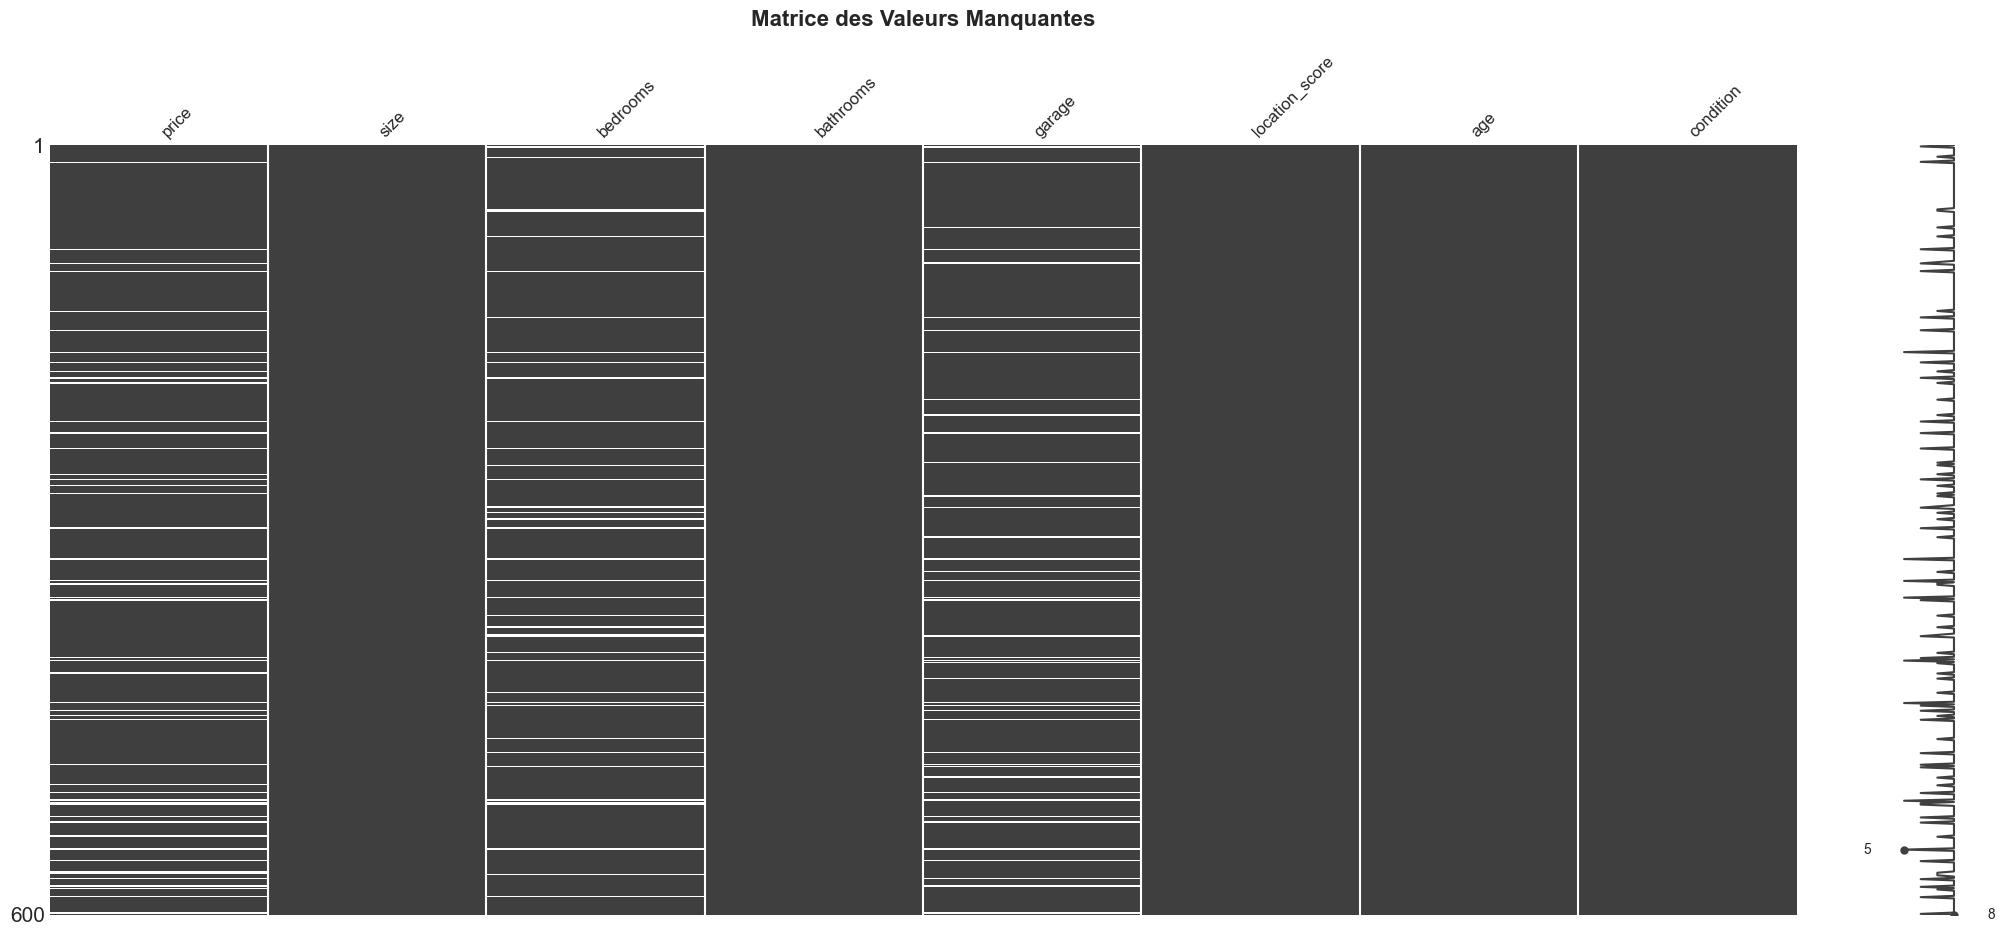


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing
price,50,8.33
garage,43,7.17
bedrooms,40,6.67


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quel est le pattern de valeurs manquantes (MCAR, MAR, MNAR) ?
2. Y a-t-il une corrélation entre les variables avec missing values ?
3. Quelle méthode d'imputation serait la plus appropriée ?
4. Comment la moyenne change-t-elle avec différentes imputations ?
5. L'imputation par KNN préserve-t-elle mieux les corrélations ?
6. Combien de voisins (k) semble optimal pour KNN ?
7. MICE converge-t-il rapidement (nombre d'itérations) ?
8. Y a-t-il des différences significatives entre les méthodes ?
9. Faut-il créer des indicateurs de missingness ?
10. Quelle méthode préserve le mieux la distribution originale ?


In [4]:
#  Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Analyser le pattern de missing values (msno.matrix, heatmap)
### Étape 2: Créer des indicateurs de missingness avant imputation
### Étape 3: Séparer en train/test pour évaluer les imputations
### Étape 4: Implémenter l'imputation par moyenne/médiane (baseline)
### Étape 5: Implémenter KNN Imputation avec k=5
### Étape 6: Implémenter MICE (Iterative Imputer)
### Étape 7: Comparer les distributions avant/après pour chaque méthode
### Étape 8: Calculer les métriques de qualité d'imputation
### Étape 9: Visualiser les corrélations préservées
### Étape 10: Sélectionner la meilleure méthode et justifier


<Figure size 1400x800 with 0 Axes>

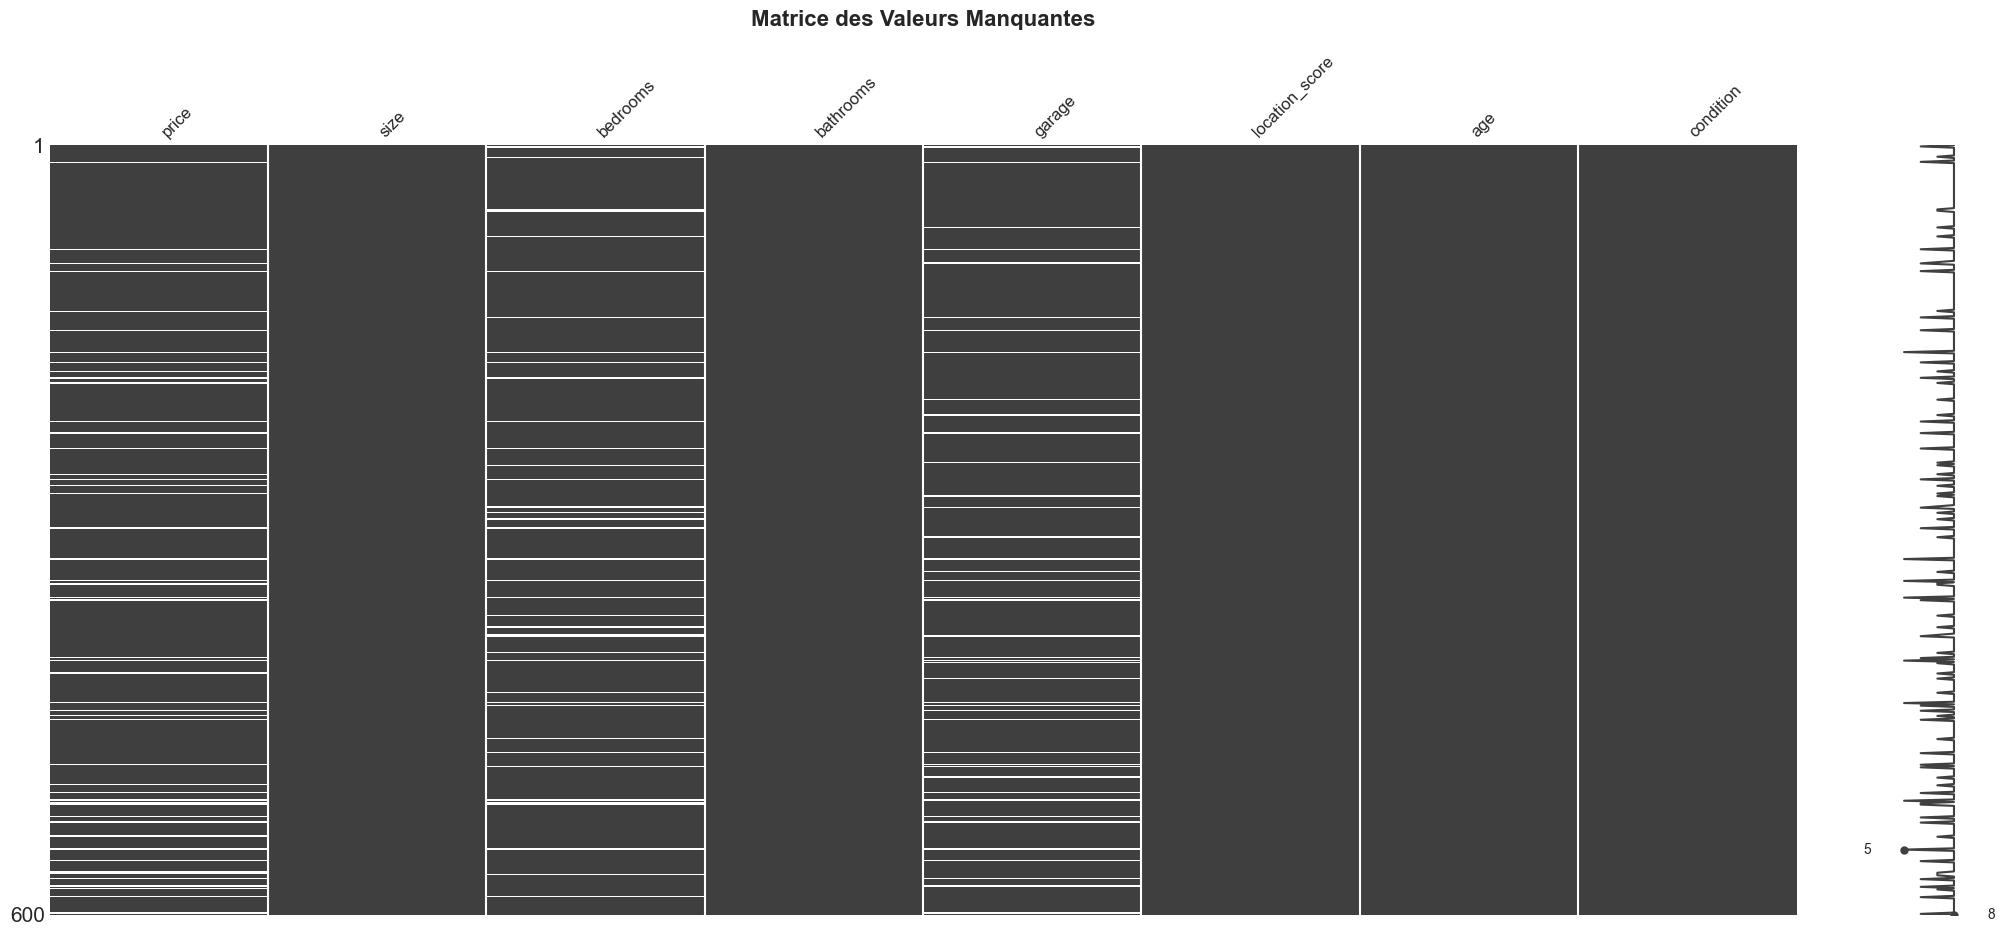

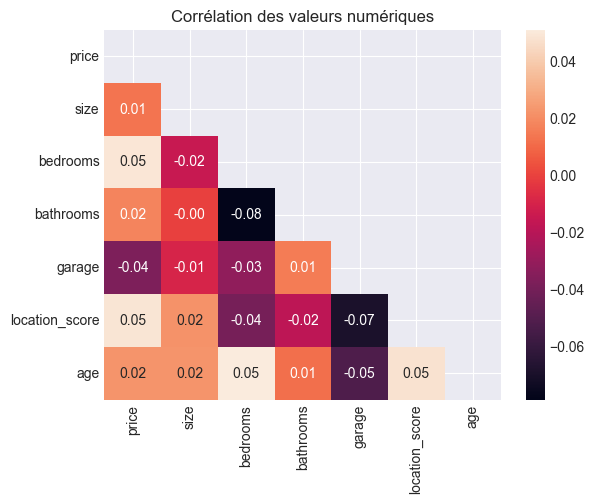

 Étape 1 complétée


In [ ]:
# ========================================
# Étape 1: Analyser le pattern de missing values (msno.matrix, heatmap)
# ========================================

# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8)) # taille en pouces
msno.matrix(df, fontsize=12, sparkline=True) # le sparkline affiche une barre a droite de la matrice, avec les pics de valeurs manquantes
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Heatmap des corrélations
df_numeric_only = df.drop([0]).corr(numeric_only=True) # recup des valeurs numeriaues
tritri = np.triu(df_numeric_only) # masque pour filtrer le triangle du haut de la heatmap
sns.heatmap(df_numeric_only, mask=tritri, annot=True, fmt=".2f") # creation de la heatmap, avec valeur pour chaque case, arrondi a 2 chiffres apres la virgule
plt.title("Corrélation des valeurs numériques")
plt.show()

# Vérification
print(f" Étape 1 complétée")

In [6]:
# ========================================
# Étape 2: Créer des indicateurs de missingness avant imputation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [7]:
# ========================================
# Étape 3: Séparer en train/test pour évaluer les imputations
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 3 complétée")

 Étape 3 complétée


In [8]:
# ========================================
# Étape 4: Implémenter l'imputation par moyenne/médiane (baseline)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 4 complétée")

 Étape 4 complétée


In [9]:
# ========================================
# Étape 5: Implémenter KNN Imputation avec k=5
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [10]:
# ========================================
# Étape 6: Implémenter MICE (Iterative Imputer)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [11]:
# ========================================
# Étape 7: Comparer les distributions avant/après pour chaque méthode
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


In [12]:
# ========================================
# Étape 8: Calculer les métriques de qualité d'imputation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 8 complétée")

 Étape 8 complétée


In [13]:
# ========================================
# Étape 9: Visualiser les corrélations préservées
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [14]:
# ========================================
# Étape 10: Sélectionner la meilleure méthode et justifier
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [15]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (600, 8)
Dimensions_finales...................... (600, 8)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
